# **랭체인 Multi-modal RAG 구현 [옵션 2]**


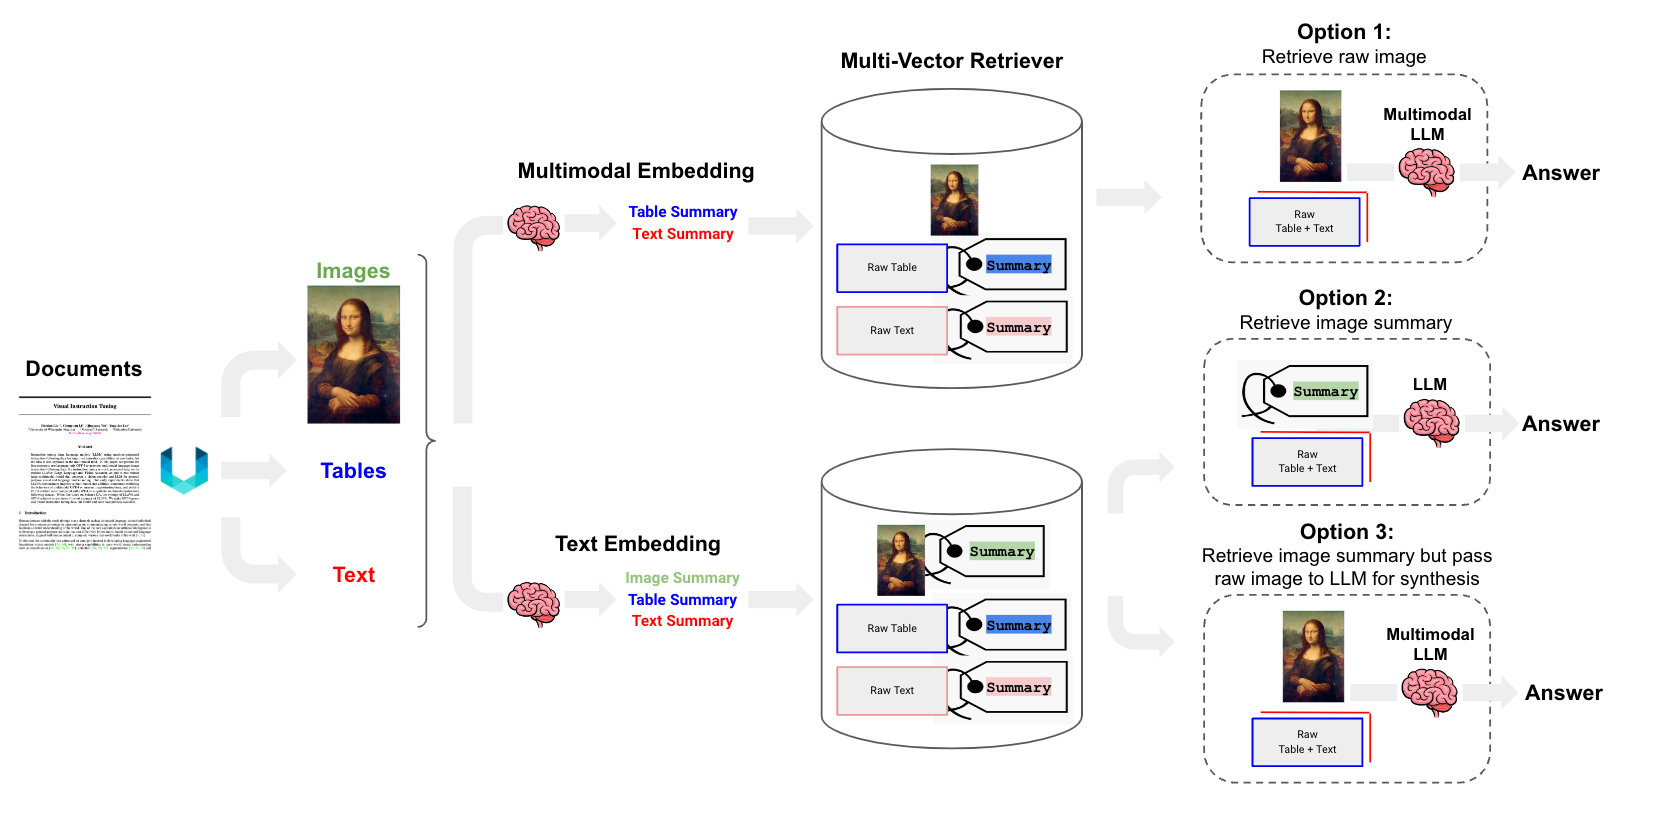

- 이미지 출처: https://github.com/langchain-ai/langchain/blob/master/cookbook/Semi_structured_and_multi_modal_RAG.ipynb

**3가지 옵션 비교:**

| 옵션 | 임베딩 방식 | 벡터 DB 저장 | 답변 생성 LLM | 이미지 활용 | 장점 | 단점 |
|---|---|---|---|---|---|---|
| 1 | 멀티모달 (CLIP) | 이미지 임베딩, 텍스트 임베딩 | Multimodal | 직접 활용 (base64) | 최고 이미지 활용도, 높은 답변 품질 | 높은 비용, base64 오버헤드 |
| 2 | 텍스트 (OpenAI) | 텍스트 임베딩 (이미지 요약) | Text-only | 텍스트 요약 간접 활용 | 비용 효율성, 텍스트 RAG 인프라 활용 | 이미지 정보 손실, 답변 품질 제한적 |
| 3 | 텍스트 (OpenAI) | 텍스트 임베딩 (이미지 요약 + 참조) | Multimodal | 원본 이미지 참조 활용 | 옵션 1과 2의 절충, 이미지 정보 손실 감소, 유연성 | 옵션 1보다 이미지 활용도 낮음, 이미지 참조 관리 필요 |

**선택 가이드:**

* **최고 품질 답변:** 옵션 1 (비용 고려)
* **비용 효율성 우선:** 옵션 2 (답변 품질 제한 감수)
* **품질과 효율성 균형:** 옵션 3

---

`(1) Env 환경변수`

In [1]:
from dotenv import load_dotenv
load_dotenv()

True

`(2) 기본 라이브러리`

In [2]:
import os
from glob import glob

from pprint import pprint
import json

import pandas as pd
import numpy as np

import warnings
warnings.filterwarnings('ignore')

`(3) langfuase handler 설정`

In [3]:
from langfuse.langchain import CallbackHandler

# 콜백 핸들러 생성
langfuse_handler = CallbackHandler()

`(4) 유틸리티 함수`

In [4]:
import base64
import io
from io import BytesIO

import numpy as np
from PIL import Image
from IPython.display import HTML, display
from langchain_core.documents import Document

import pickle
from langchain_core.stores import InMemoryStore


def is_base64(s):
    """문자열이 Base64로 인코딩되었는지 확인합니다"""
    try:
        return base64.b64encode(base64.b64decode(s)) == s.encode()
    except Exception:
        return False


def split_image_text_types(docs):
    """numpy 배열 이미지와 텍스트를 분리합니다"""
    images = []
    text = []
    for doc in docs:
        if isinstance(doc, str):
            pass
        elif isinstance(doc, Document):
            doc = doc.page_content  # 문서 내용 추출
        else:
            doc = doc.text # 문서 내용 추출

        if is_base64(doc):
            images.append(doc)  # base64로 인코딩된 문자열
        else:
            text.append(doc)
    return {"images": images, "texts": text}


def plt_img_base64(img_base64):
    """
    Base64로 인코딩된 이미지를 주피터 노트북에 표시
    
    매개변수:
    img_base64 (str): Base64로 인코딩된 이미지 문자열
    """
    # Base64 문자열을 소스로 하는 HTML img 태그 생성
    image_html = f'<img src="data:image/jpeg;base64,{img_base64}" />'

    # HTML을 렌더링하여 이미지 표시
    display(HTML(image_html))

---

## **증권사 분석보고서 문서 로드**

- PDF 문서에서 이미지, 텍스트, 테이블 분리


### 1. **데이터 로딩 및 파싱** 

- 메모리 부족할 경우 별도의 실습파일을 활용 

In [5]:
# 데이터 저장 폴더 경로
data_path = "data/analyst_reports/" 

# PDF 파일이 있는  경로
pdf_files = glob(os.path.join(data_path, "*.pdf"))  

# 이미지를 저장할 경로
image_output_dir = os.path.join(data_path, 'images')  

os.makedirs(image_output_dir, exist_ok=True)

print(f"PDF files:")
pprint(pdf_files)

PDF files:
['data/analyst_reports\\20240524_company_234017000.pdf',
 'data/analyst_reports\\20240531_company_652771000.pdf',
 'data/analyst_reports\\20240531_company_753270000.pdf']


In [6]:
from unstructured.partition.pdf import partition_pdf
from unstructured.cleaners.core import (
    clean_extra_whitespace,
    group_broken_paragraphs
)

# PDF 파일을 로드하고 파티셔닝
pdf_chunks = []
for pdf_file in pdf_files:
    chunks = partition_pdf(
        filename=pdf_file,
        strategy="hi_res",              
        infer_table_structure=True,    
        languages=["eng", "kor"],           
        
        # 이미지 추출 설정     
        extract_image_block_types=["Image", "Table"],
        # extract_image_block_output_dir=image_output_dir,   # 이미지 저장 경로
        extract_image_block_to_payload=True, # base64로 저장

        # 후처리 설정
        post_processors=[
            group_broken_paragraphs,
            clean_extra_whitespace,
            ], 

        # 문서 청킹 설정
        chunking_strategy="by_title",
        max_characters=1200,   
        new_after_n_chars=800,
        combine_text_under_n_chars=600,    

    )
    pdf_chunks.extend(chunks)


# 청크 개수 확인
print(len(pdf_chunks))

W1202 18:17:52.808000 32480 site-packages\torch\distributed\elastic\multiprocessing\redirects.py:29] NOTE: Redirects are currently not supported in Windows or MacOs.
The `max_size` parameter is deprecated and will be removed in v4.26. Please specify in `size['longest_edge'] instead`.


33


In [7]:
# 타입별 분석
chunk_types = {}
for chunk in pdf_chunks:
    chunk_type = str(type(chunk))
    if chunk_type in chunk_types:
        chunk_types[chunk_type] += 1
    else:
        chunk_types[chunk_type] = 1

print("📋 청크 타입 분포:")
for chunk_type, count in chunk_types.items():
    print(f"  • {chunk_type.split('.')[-1].replace('>', '')}: {count}개")

📋 청크 타입 분포:
  • CompositeElement': 27개
  • TableChunk': 6개


In [8]:
# 청크 내용 확인
for chunk in pdf_chunks[1:3]:
    print(chunk)
    print("=" * 100)

주가(원,5/23)

183,500

시가총액(십억원) 39,818 발행주식수 216,993천주 52주 최고가 241,000원 최저가 131,000원 52주 일간 Beta 60일 일평균거래대금 1,172억원 외국인 지분율 23.9% 배당수익률(2024F) 0.3% 주주구성 셀트리온홀딩스 (외 86인) 28.3% 국민연금공단 (외 1인) 5.3% 자사주 (외 1인) 4.8% 주가상승(%) 1M 6M 12M 상대기준 -1.7 -2.1 절대기준 2.1 6.1 현재 직전 변동 투자의견 BUY BUY - 목표주가 250,000 250,000 - 영업이익(24) 569 569 -

2,284 2,176 3,499 4,671

569 1,806

577 1,808

464 1,452

3,676 2,432 2,104 6,592

0.93

-13.5 213.2

27.8

8.1

2.2

19.5

자료: 유진투자증권

주: 2023년 12월 28일 셀트리온이 셀트리온 헬스케어를 흡수합병함에 따라 2022~2023년 실적과 2024~2025년 예상 실적의 연속성은 없음

250,000 5 200,000. - 150,000 | 100,000 - ” — #7 (4,24) 30,000 7 000 <058 지 수 대 비 ( 우 , p) 20 ' 8 23.5 23.9 24.1 24.5

-3.8

2.2

영업이익(25)

1,806

1,806

-

O12

98

개

자

셀트리온
제 3 성장기: Business Model Innovation 진행 중

기존 의견: 상반기 당사는 2024 년 3 월 4 일 발간한 셀트리온 기업분석 보고서에서 2024 년 상반 에는 보수적 접근 기에는 공격적인 매수 전략보다 보수적 접근 전략이 유효할 것으로 전망하였다. 이는 2023 년 12 월 합병 이후 신제품 출시와 합병 이후 원가율 정상화에 따른 실적 고성장 추이가 하반기부터 본격화될 것으로 판단하여 매출 성장을 확인하 고 접근하는 보수적인 접근을 권유한 것이었다.

신규 의견: 그러

In [9]:
# 청크 저장
import pickle

with open(os.path.join(data_path, "pdf_base64_chunks.pkl"), "wb") as f:
    pickle.dump(pdf_chunks, f)

In [10]:
# 청크 로드
import pickle

with open(os.path.join(data_path, "pdf_base64_chunks.pkl"), "rb") as f: 
    pdf_chunks = pickle.load(f)

# 청크 개수 확인
print(len(pdf_chunks))

33


### 2. **타입별 구조 확인** 

In [11]:
# 각 청크 문서의 타입 확인
set([str(type(el)) for el in pdf_chunks])

{"<class 'unstructured.documents.elements.CompositeElement'>",
 "<class 'unstructured.documents.elements.TableChunk'>"}

In [12]:
# CompositeElement 확인
pdf_chunks[1]

In [13]:
# CompositeElement는 하위 구성 요소를 포함하고 있음
pdf_chunks[1].metadata.orig_elements

In [14]:
# Table 객체 확인 
tab = pdf_chunks[1].metadata.orig_elements[2] 
tab.to_dict()

{'type': 'Table',
 'element_id': 'd04b6b5c-272c-468c-a861-e24e1966e9b4',
 'text': '시가총액(십억원) 39,818 발행주식수 216,993천주 52주 최고가 241,000원 최저가 131,000원 52주 일간 Beta 60일 일평균거래대금 1,172억원 외국인 지분율 23.9% 배당수익률(2024F) 0.3% 주주구성 셀트리온홀딩스 (외 86인) 28.3% 국민연금공단 (외 1인) 5.3% 자사주 (외 1인) 4.8% 주가상승(%) 1M 6M 12M 상대기준 -1.7 -2.1 절대기준 2.1 6.1 현재 직전 변동 투자의견 BUY BUY - 목표주가 250,000 250,000 - 영업이익(24) 569 569 -',
 'metadata': {'detection_class_prob': 0.8288782835006714,
  'coordinates': {'points': ((131.28814697265625, 1378.218505859375),
    (131.28814697265625, 2240.499267578125),
    (733.9306030273438, 2240.499267578125),
    (733.9306030273438, 1378.218505859375)),
   'system': 'PixelSpace',
   'layout_width': 1654,
   'layout_height': 2339},
  'last_modified': '2025-11-16T14:35:12',
  'text_as_html': '<table><tbody><tr><td>시 가 총 액 (십억원)</td><td></td><td>39,818</td></tr><tr><td colspan="3">216,993</td></tr><tr><td></td><td></td><td>241,000% 131,0008</td></tr><tr><td></td><td></td><td>0.93</td></tr><tr><td>60 일 

In [15]:
# Table 객체의 데이터프레임 변환
tab_df = pd.read_html(tab.metadata.text_as_html)[0] 

# 데이터프레임 확인
tab_df

,0,1,2
0,시 가 총 액 (십억원),NaN,39818
1,216993,216993,216993
2,NaN,NaN,"241,000% 131,0008"
3,NaN,NaN,0.93
4,60 일 일 평 균 거 래 대금,NaN,117244
5,외국인 지분율,NaN,23.9%
6,배 당 수 익 률 (2024),NaN,0.3%
7,외 %) Ole 주 가 상,6M,12M
8,FN 상 다 7,2.1,NaN
9,FN 7,61,22


In [16]:
# 데이터프레임을 마크다운 변환
tab_md = tab_df.to_markdown(index=False)
print(tab_md)

| 0                         | 1       | 2                 |
|:--------------------------|:--------|:------------------|
| 시 가 총 액 (십억원)      | nan     | 39818             |
| 216993                    | 216993  | 216993            |
| nan                       | nan     | 241,000% 131,0008 |
| nan                       | nan     | 0.93              |
| 60 일 일 평 균 거 래 대금 | nan     | 117244            |
| 외국인 지분율             | nan     | 23.9%             |
| 배 당 수 익 률 (2024)     | nan     | 0.3%              |
| 외 %) Ole 주 가 상        | 6M      | 12M               |
| FN 상 다 7                | 2.1     | nan               |
| FN 7                      | 61      | 22                |
| nan                       | 직전    | nan               |
| 투 자 의견                | BUY     | -                 |
| 목 표 주가 250,000        | 250000  | -                 |
| 영 업 이 익 (24)          | 569     | -                 |
| 연어 1601/32              | 41 QNnK | .                 |



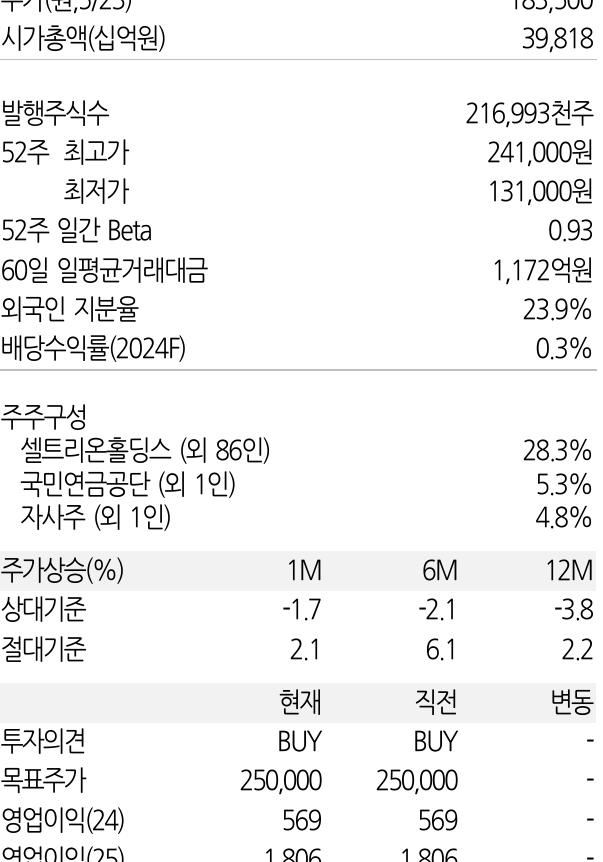

In [17]:
# image_base64 이미지 확인
plt_img_base64(tab.metadata.image_base64)

In [18]:
# TableChunk 객체 확인
for i, c in enumerate(pdf_chunks):
    if "TableChunk" in str(type(c)):
        print(f"TableChunk {i}:")
        print(c)
        print("=" * 100)

TableChunk 8:
손 익 계산서 ( 단 위 : 십 억원) 20224 2023A 2024F 2025F 2026F 매출액 2284 2176 3499 _ 4671 _ 4972 증 가 율 (%) 206 (07) 608 335 64 매출원가 1251 _ 1125 _ 1752 _ 1449 _ 1442 매 출 총 이익 1033 1,052 1747 _ 3222 3530 판매 및 일 반 관리비 385 400 _ 1178 _ 1416 _ 1608 기 타 영 업 손익 12 4 194 20 14 영 업 이익 6497 651 569 1806 1923 증 가 율 (%) (130) 07 (127) 2174 65 EBITDA 874 897 771 2103 _ 2283 증 가 율 (%) 688 27 041 1728 85 영 업 외 손 익 (21) 20 8 2 (6) 이 자 수익 14 19 19 19 19 이 자 비용 8 10 14 14 14 지 분 법 손익 7 (13) 0 0 0 기 영 업 손익 (35) B 3 @ (10 타 세 전 순이익 626 671 577 1808 = 1918 증 가 율 (%) 052 72 040 2133 61 법 인 세 95 131 113 356 391 비용 당 기 순이익 543 540 464 1452 1527 증 가 율 (%) 69 (05 (141) 2132 52 지 배 주 주 지분 538 536 464 1452 1527 증 가 율 (%) 02) 04 035 2132 52 배 비 지 지 분 5 4 0 0 0 태 원 5( ) 3676 2432 2104 6592 6,932 증 가 (%) 03) 639 035) _ 2132 52 율 수 정 505( 원 ) 3676 2432 2104 6592 _ 6932 증 가 율 (%) 03) 639 035) _ 2132 52 주 요 투 자 지표 20224 2023A 2024F 2025F 2026F 주 당 지 표 (원) EPS 3676 2432 2104 6592 6,932 BPS 29398 77,083 78478 84570 91,

In [19]:
# TableChunk 객체 확인
pdf_chunks[4].metadata.orig_elements

In [20]:
tab = pdf_chunks[4].metadata.orig_elements[0]

# Table 객체 확인
tab.to_dict()

{'type': 'NarrativeText',
 'element_id': '71cabb7d-8cdc-4fe3-ace7-62a67b27b701',
 'text': 'Eugene Research Center _3',
 'metadata': {'detection_class_prob': 0.4910798668861389,
  'coordinates': {'points': ((1210.5872802734375, 2229.626953125),
    (1210.5872802734375, 2256.375244140625),
    (1464.7930764444443, 2256.375244140625),
    (1464.7930764444443, 2229.626953125)),
   'system': 'PixelSpace',
   'layout_width': 1654,
   'layout_height': 2339},
  'last_modified': '2025-11-16T14:35:12',
  'filetype': 'PPM',
  'languages': ['eng', 'kor'],
  'page_number': 3}}

In [21]:
# Table 객체의 데이터프레임 변환
# text_as_html이 None인 경우 디버깅 정보 출력

chunk_idx = 4
element_idx = 0

# 디버깅: 청크 정보 확인
print(f"📌 대상 청크: pdf_chunks[{chunk_idx}]")
print(f"   청크 타입: {type(pdf_chunks[chunk_idx])}")

if hasattr(pdf_chunks[chunk_idx], 'metadata') and hasattr(pdf_chunks[chunk_idx].metadata, 'orig_elements'):
    orig_elements = pdf_chunks[chunk_idx].metadata.orig_elements
    print(f"   orig_elements 개수: {len(orig_elements)}")
    
    if len(orig_elements) > element_idx:
        target_element = orig_elements[element_idx]
        print(f"\n📌 대상 요소: orig_elements[{element_idx}]")
        print(f"   요소 타입: {type(target_element)}")
        
        if hasattr(target_element, 'metadata'):
            print(f"   metadata 속성들: {[attr for attr in dir(target_element.metadata) if not attr.startswith('_')]}")
            
            # text_as_html 확인
            if hasattr(target_element.metadata, 'text_as_html'):
                table_html = target_element.metadata.text_as_html
                print(f"   text_as_html: {'있음' if table_html else 'None'}")
                
                if table_html is not None:
                    table_df = pd.read_html(table_html)[0]
                    print(f"\n✅ 테이블 변환 성공!")
                    display(table_df)
                else:
                    print(f"\n⚠️ text_as_html이 None입니다.")
                    print(f"   → PDF 파싱 시 테이블 구조 추출 실패")
                    print(f"   → cell-12 또는 cell-31의 partition_pdf 실행 결과 확인 필요")
                    print(f"   → infer_table_structure=True 옵션이 적용되었는지 확인")
                    
                    # 대체 테이블 찾기
                    print(f"\n🔍 text_as_html이 있는 테이블 요소 검색 중...")
                    found_tables = []
                    for i, chunk in enumerate(pdf_chunks):
                        if hasattr(chunk, 'metadata') and hasattr(chunk.metadata, 'orig_elements'):
                            for j, el in enumerate(chunk.metadata.orig_elements):
                                if hasattr(el, 'metadata') and hasattr(el.metadata, 'text_as_html'):
                                    if el.metadata.text_as_html is not None:
                                        found_tables.append((i, j, type(el).__name__))
                    
                    if found_tables:
                        print(f"   발견된 테이블 {len(found_tables)}개:")
                        for i, j, el_type in found_tables[:5]:  # 최대 5개만 표시
                            print(f"   - pdf_chunks[{i}].metadata.orig_elements[{j}] ({el_type})")
                        
                        # 첫 번째 유효한 테이블 표시
                        first_i, first_j, _ = found_tables[0]
                        table_df = pd.read_html(pdf_chunks[first_i].metadata.orig_elements[first_j].metadata.text_as_html)[0]
                        print(f"\n📊 대체 테이블 (pdf_chunks[{first_i}].orig_elements[{first_j}]):")
                        display(table_df)
                    else:
                        print(f"   ❌ text_as_html이 있는 테이블을 찾을 수 없습니다.")
            else:
                print(f"   ⚠️ text_as_html 속성이 없습니다.")
        else:
            print(f"   ⚠️ metadata 속성이 없습니다.")
    else:
        print(f"   ⚠️ orig_elements[{element_idx}]가 존재하지 않습니다. (총 {len(orig_elements)}개)")
else:
    print(f"   ⚠️ orig_elements 속성이 없습니다.")

📌 대상 청크: pdf_chunks[4]
   청크 타입: <class 'unstructured.documents.elements.CompositeElement'>
   orig_elements 개수: 8

📌 대상 요소: orig_elements[0]
   요소 타입: <class 'unstructured.documents.elements.NarrativeText'>
   metadata 속성들: ['DEBUG_FIELD_NAMES', 'coordinates', 'detection_class_prob', 'fields', 'filetype', 'from_dict', 'known_fields', 'languages', 'last_modified', 'links', 'page_number', 'to_dict', 'update']
   text_as_html: None

⚠️ text_as_html이 None입니다.
   → PDF 파싱 시 테이블 구조 추출 실패
   → cell-12 또는 cell-31의 partition_pdf 실행 결과 확인 필요
   → infer_table_structure=True 옵션이 적용되었는지 확인

🔍 text_as_html이 있는 테이블 요소 검색 중...
   발견된 테이블 25개:
   - pdf_chunks[0].metadata.orig_elements[20] (Table)
   - pdf_chunks[1].metadata.orig_elements[2] (Table)
   - pdf_chunks[6].metadata.orig_elements[10] (Table)
   - pdf_chunks[8].metadata.orig_elements[0] (Table)
   - pdf_chunks[9].metadata.orig_elements[0] (Table)

📊 대체 테이블 (pdf_chunks[0].orig_elements[20]):


,Unnamed: 0,"2,284","2,176","3,499"
0,NaN,647.0,651,569.0
1,NaN,626.0,671,577.0
2,NaN,543.0,540,464.0
3,NaN,3676.0,2432,2104.0
4,NaN,73.0,“33.9,-13.5
5,NaN,437.0,829,87.2
6,ROE(%),134.0,5.1,27.0
7,PBR(tH),5.5,26,23.0
8,EV/EBITDA(HH),26.1,34.1,53.2


### 3. **표 가장자리 인식 개선 [참고]** 

- 테이블 이미지의 가장자리가 잘리는 문제를 해결하기 위해 환경 변수를 통해 패딩을 조정할 수 있음.
- 패딩 값은 문서의 복잡성과 테이블 크기에 따라 조정이 필요할 수 있으므로, 최적의 결과를 위해 다양한 값으로 테스트해보는 것이 필요.

    ```env
    # .env 파일에 추가
    # 테이블 이미지의 가장자리 인식 개선을 위한 패딩 설정
    EXTRACT_IMAGE_BLOCK_CROP_HORIZONTAL_PAD=20
    EXTRACT_IMAGE_BLOCK_CROP_VERTICAL_PAD=10
    ```

- **커널 재시작 후 적용됨**

In [22]:
# 데이터 저장 폴더 경로
data_path = "data/analyst_reports/" 

# PDF 파일이 있는  경로
pdf_files = glob(os.path.join(data_path, "*.pdf"))  

# 이미지를 저장할 경로
image_output_dir = os.path.join(data_path, 'images_pad_with_w20_h10')  

os.makedirs(image_output_dir, exist_ok=True)

print(f"PDF files:")
pprint(pdf_files)

PDF files:
['data/analyst_reports\\20240524_company_234017000.pdf',
 'data/analyst_reports\\20240531_company_652771000.pdf',
 'data/analyst_reports\\20240531_company_753270000.pdf']


In [23]:
from unstructured.partition.pdf import partition_pdf
from unstructured.cleaners.core import (
    clean_extra_whitespace,
    group_broken_paragraphs
)

# PDF 파일을 로드하고 파티셔닝
pdf_chunks = []
for pdf_file in pdf_files:
    chunks = partition_pdf(
        filename=pdf_file,
        strategy="hi_res",              
        infer_table_structure=True,    
        languages=["eng", "kor"],           
        
        # 이미지 추출 설정     
        extract_image_block_types=["Image", "Table"],
        # extract_image_block_output_dir=image_output_dir,   # 이미지 저장 경로
        extract_image_block_to_payload=True, # base64로 저장

        # 후처리 설정
        post_processors=[
            group_broken_paragraphs,
            clean_extra_whitespace,
            ], 

        # 문서 청킹 설정
        chunking_strategy="by_title",
        max_characters=1200,   
        new_after_n_chars=800,
        combine_text_under_n_chars=600,    

    )
    pdf_chunks.extend(chunks)


# 청크 개수 확인
print(len(pdf_chunks))

33


In [24]:
# 타입별 분석
chunk_types = {}
for chunk in pdf_chunks:
    chunk_type = str(type(chunk))
    if chunk_type in chunk_types:
        chunk_types[chunk_type] += 1
    else:
        chunk_types[chunk_type] = 1

print("📋 청크 타입 분포:")
for chunk_type, count in chunk_types.items():
    print(f"  • {chunk_type.split('.')[-1].replace('>', '')}: {count}개")

📋 청크 타입 분포:
  • CompositeElement': 27개
  • TableChunk': 6개


In [25]:
# 청크 내용 확인
for chunk in pdf_chunks[1:3]:
    print(chunk)
    print("=" * 100)

주가(원,5/23)

183,500

시가총액(십억원) 39,818 발행주식수 216,993천주 52주 최고가 241,000원 최저가 131,000원 52주 일간 Beta 60일 일평균거래대금 1,172억원 외국인 지분율 23.9% 배당수익률(2024F) 0.3% 주주구성 셀트리온홀딩스 (외 86인) 28.3% 국민연금공단 (외 1인) 5.3% 자사주 (외 1인) 4.8% 주가상승(%) 1M 6M 12M 상대기준 -1.7 -2.1 절대기준 2.1 6.1 현재 직전 변동 투자의견 BUY BUY - 목표주가 250,000 250,000 - 영업이익(24) 569 569 -

2,284 2,176 3,499 4,671

569 1,806

577 1,808

464 1,452

3,676 2,432 2,104 6,592

0.93

-13.5 213.2

27.8

8.1

2.2

19.5

자료: 유진투자증권

주: 2023년 12월 28일 셀트리온이 셀트리온 헬스케어를 흡수합병함에 따라 2022~2023년 실적과 2024~2025년 예상 실적의 연속성은 없음

250,000 5 200,000. - 150,000 | 100,000 - ” — #7 (4,24) 30,000 7 000 <058 지 수 대 비 ( 우 , p) 20 ' 8 23.5 23.9 24.1 24.5

-3.8

2.2

영업이익(25)

1,806

1,806

-

O12

98

개

자

셀트리온
제 3 성장기: Business Model Innovation 진행 중

기존 의견: 상반기 당사는 2024 년 3 월 4 일 발간한 셀트리온 기업분석 보고서에서 2024 년 상반 에는 보수적 접근 기에는 공격적인 매수 전략보다 보수적 접근 전략이 유효할 것으로 전망하였다. 이는 2023 년 12 월 합병 이후 신제품 출시와 합병 이후 원가율 정상화에 따른 실적 고성장 추이가 하반기부터 본격화될 것으로 판단하여 매출 성장을 확인하 고 접근하는 보수적인 접근을 권유한 것이었다.

신규 의견: 그러

In [26]:
# TableChunk 객체 확인
for i, c in enumerate(pdf_chunks):
    if "TableChunk" in str(type(c)):
        print(f"TableChunk {i}:")
        print(c)
        print("=" * 100)

TableChunk 8:
손 익 계산서 ( 단 위 : 십 억원) 20224 2023A 2024F 2025F 2026F 매출액 2284 2176 3499 _ 4671 _ 4972 증 가 율 (%) 206 (07) 608 335 64 매출원가 1251 _ 1125 _ 1752 _ 1449 _ 1442 매 출 총 이익 1033 1,052 1747 _ 3222 3530 판매 및 일 반 관리비 385 400 _ 1178 _ 1416 _ 1608 기 타 영 업 손익 12 4 194 20 14 영 업 이익 6497 651 569 1806 1923 증 가 율 (%) (130) 07 (127) 2174 65 EBITDA 874 897 771 2103 _ 2283 증 가 율 (%) 688 27 041 1728 85 영 업 외 손 익 (21) 20 8 2 (6) 이 자 수익 14 19 19 19 19 이 자 비용 8 10 14 14 14 지 분 법 손익 7 (13) 0 0 0 기 영 업 손익 (35) B 3 @ (10 타 세 전 순이익 626 671 577 1808 = 1918 증 가 율 (%) 052 72 040 2133 61 법 인 세 95 131 113 356 391 비용 당 기 순이익 543 540 464 1452 1527 증 가 율 (%) 69 (05 (141) 2132 52 지 배 주 주 지분 538 536 464 1452 1527 증 가 율 (%) 02) 04 035 2132 52 배 비 지 지 분 5 4 0 0 0 태 원 5( ) 3676 2432 2104 6592 6,932 증 가 (%) 03) 639 035) _ 2132 52 율 수 정 505( 원 ) 3676 2432 2104 6592 _ 6932 증 가 율 (%) 03) 639 035) _ 2132 52 주 요 투 자 지표 20224 2023A 2024F 2025F 2026F 주 당 지 표 (원) EPS 3676 2432 2104 6592 6,932 BPS 29398 77,083 78478 84570 91,

In [27]:
# 청크 로드
import pickle

with open(os.path.join(data_path, "pdf_base64_chunks.pkl"), "rb") as f: 
    pdf_chunks = pickle.load(f)

# 청크 개수 확인
print(len(pdf_chunks))

33


---

## **[옵션 2]** 멀티모달 LLM으로 이미지 요약을 활용해서 생성

- **멀티모달 LLM** 모델(GPT4-V, LLaVA 등)을 사용하여 이미지에서 **텍스트 요약**을 생성
- 생성된 텍스트를 **임베딩**하고 필요할 때 **검색**
- 검색된 텍스트 **청크**를 LLM에 전달하여 최종 **답변을 합성**
- 이미지를 직접 벡터화하는 대신 이미지에서 **추출한 텍스트 정보**를 활용

### 1. **타입 별로 구분해서 요약 생성** 

- Table, Text, 이미지 요소를 구분해서 정리
- Table -> 텍스트 요약 
- Image -> 텍스트 요약

`(1) 타입별 구분`

In [28]:
# 타입별 분류
tables = []
texts = []
images = []

for chunk in pdf_chunks:
    # 테이블 청크
    if "Table" in str(type(chunk)):
        tables.append(chunk)
    
    # 텍스트 청크 (CompositeElement)
    elif "CompositeElement" in str(type(chunk)):
        texts.append(chunk)

# 이미지 추출 (metadata에서)
for chunk in pdf_chunks:
    if hasattr(chunk, 'metadata') and hasattr(chunk.metadata, 'orig_elements'):
        for el in chunk.metadata.orig_elements:
            # 이미지 요소가 있는 경우만 추출
            if hasattr(el.metadata, 'image_base64') and el.metadata.image_base64:
                images.append(el.metadata.image_base64)

print(f"📊 테이블 청크: {len(tables)}개")
print(f"📝 텍스트 청크: {len(texts)}개")
print(f"🖼️ 이미지: {len(images)}개")

📊 테이블 청크: 6개
📝 텍스트 청크: 27개
🖼️ 이미지: 42개


In [29]:
# 테이블 청크 확인
tables[0]

In [30]:
# 텍스트 청크 확인
texts[0]


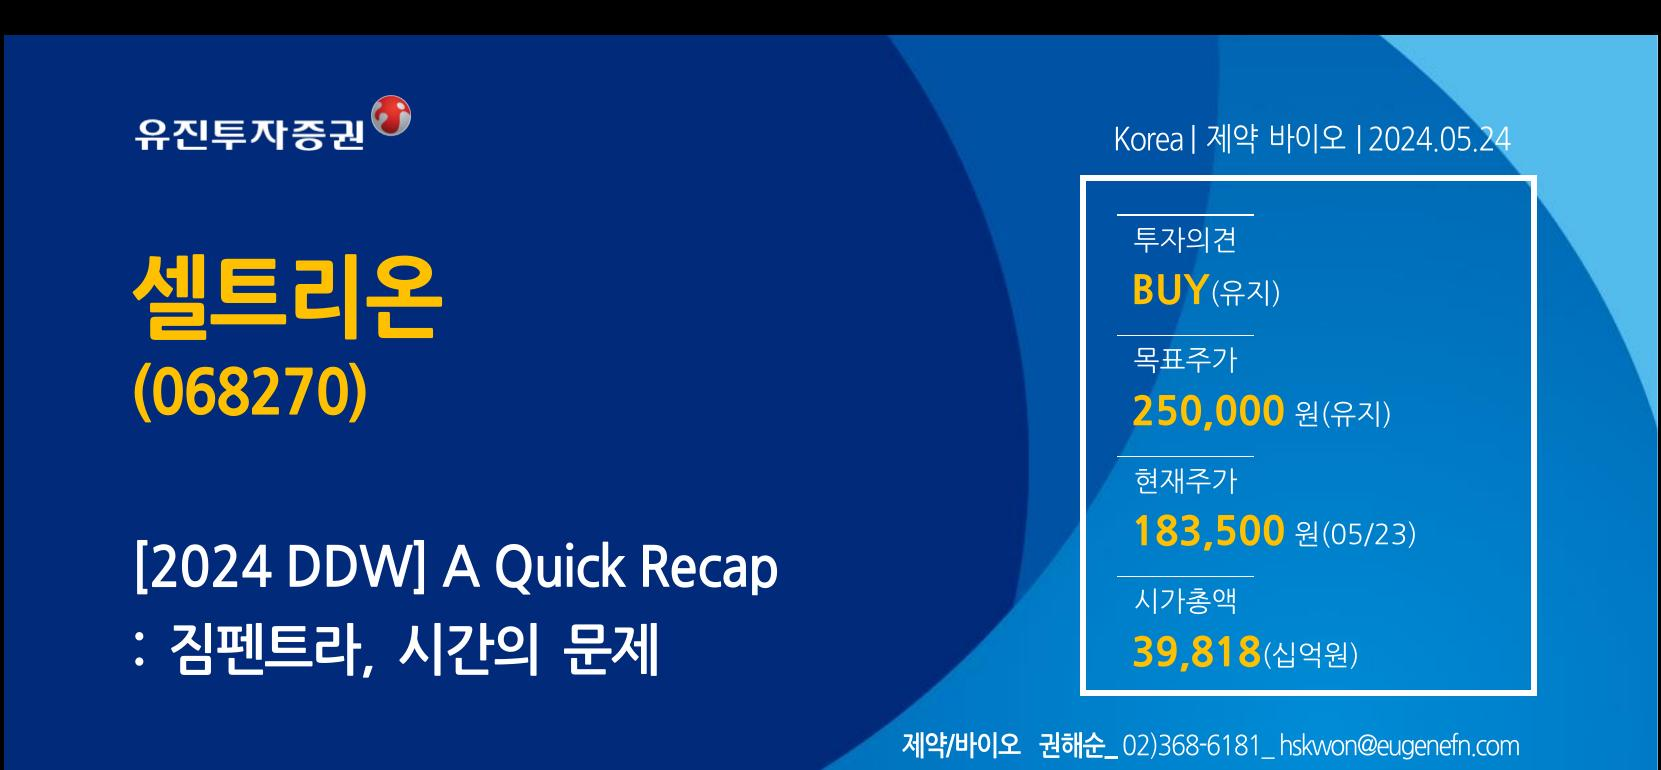

In [31]:
# 이미지 청크 확인
plt_img_base64(images[0])

`(2) Table/Text 요약 체인`

In [32]:
from langchain_core.output_parsers import StrOutputParser
from langchain_core.prompts import ChatPromptTemplate
from langchain_openai import ChatOpenAI

# 프롬프트 템플릿 설정
prompt_text = """
다음 텍스트나 표를 한국어로 간결하게 요약하세요.
핵심 정보와 수치 데이터를 포함하되, 불필요한 설명은 제외하세요.

요약할 내용:
{element}

요약:
"""
prompt = ChatPromptTemplate.from_template(prompt_text)

# 요약 체인 생성 (수정: gpt-4.1-mini → gpt-4o-mini)
model = ChatOpenAI(temperature=0, model="gpt-4o-mini")
summarize_chain = prompt | model | StrOutputParser()

In [33]:
# 텍스트 요약 테스트
text_summary = summarize_chain.invoke(texts[0])
print(text_summary)

**셀트리온 투자 정보 (2024.05.24)**  
- **투자의견:** BUY(유지)  
- **목표주가:** 250,000 원(유지)  
- **현재주가:** 183,500 원 (05/23)  
- **시가총액:** 39,818 억 원  

**IBD 치료제 시장 동향:**  
- 염증성 장질환 유병률 상승으로 신제품 및 바이오시밀러 출시 증가  
- 주요 기업: 다케다, J&J, 애브비, 셀트리온  

**셀트리온 전략:**  
- 짐펜트라로 외형 및 이익 성장 목표  
- 2024 DDW에서 의료진의 높은 관심 확인  
- TNF-α 치료제 시장 점유율 상승 예상  

**재무 정보 (십억원):**  
- 2022A: 매출 647, 영업이익 651, 순이익 543  
- 2023A: 매출 626, 영업이익 671, 순이익 540  
- 2024E: 매출 671, 영업이익 540  
- **EPS:** 2023A -33.9% 감소  
- **PER:** 2023A 82.9배, 2024E 87.2배  
- **ROE:** 2023A 5.1%, 2024E 2.7%  
- **PBR:** 2023A 2.6배, 2024E 2.3배  
- **EV/EBITDA:** 2023A 34.1배, 2024E 53.2배  


In [34]:
# 테이블 요약 테스트
table_summary = summarize_chain.invoke(tables[0])
print(table_summary)

**손익 계산서 요약 (단위: 십억 원)**

- **매출액**: 
  - 2022: 2284, 2023: 2176, 2024F: 3499, 2025F: 4671, 2026F: 4972
  - 증가율: 2023(-4.7%), 2024(60.8%), 2025(33.5%), 2026(6.4%)

- **매출원가**: 
  - 2022: 1251, 2023: 1125, 2024F: 1752, 2025F: 1449, 2026F: 1442

- **영업 이익**: 
  - 2022: 649, 2023: 651, 2024F: 569, 2025F: 1806, 2026F: 1923
  - 증가율: 2023(0.3%), 2024(-12.7%), 2025(217.4%), 2026(6.5%)

- **순이익**: 
  - 2022: 626, 2023: 671, 2024F: 577, 2025F: 1808, 2026F: 1918
  - 증가율: 2023(7.2%), 2024(-14.0%), 2025(213.3%), 2026(6.1%)

- **주요 투자 지표**:
  - EPS: 2022: 3676, 2023: 2432, 2024F: 2104, 2025F: 6592, 2026F: 6932
  - PER: 2022: 43.7, 2023: 68.3, 2024F: 87.2, 2025F: 27.8, 2026F: 26.5
  - 배당 수익률: 2022: 0.2%, 2023: 0.2%, 2024F: 0.3%, 2025F: 0.3%, 2026F: 0.3%

- **영업 이익률**: 
  - 2022: 28.3%, 2023: 29.9%, 2024F: 16.3%, 2025F: 38.7%, 2026F: 38.7%


In [35]:
# 텍스트 요약
text_summaries = summarize_chain.batch(
    texts, 
    {"max_concurrency": 3}     # 동시 실행 개수 설정
    )

# 테이블 요약
table_summaries = summarize_chain.batch(
    tables, 
    {"max_concurrency": 3}     # 동시 실행 개수 설정
)

print(f"Text 요약 개수: {len(text_summaries)}")
print(f"Table 요약 개수: {len(table_summaries)}")

Text 요약 개수: 27
Table 요약 개수: 6


`(3) 이미지 캡션 요약 체인`

In [36]:
from langchain_openai import ChatOpenAI

# 이미지 요약 프롬프트 템플릿 설정
messages = [
    (
        "user",
        [
            {
                "type": "text", 
                "text": """
                이 이미지를 자세히 분석하고 한국어로 설명하세요. 
                특히 다음 사항에 주의하세요:
                
                1. 차트나 그래프의 경우: 데이터 트렌드, 수치, 비교 포인트
                2. 다이어그램의 경우: 구조, 연결관계, 프로세스 흐름
                3. 표의 경우: 주요 데이터 포인트와 패턴
                4. 일반 이미지의 경우: 주요 객체, 텍스트, 맥락
                
                분석 결과를 구체적이고 정확하게 기술하세요.
                """
            },
            {
                "type": "image_url",
                "image_url": {"url": "data:image/jpeg;base64,{image}"},
            },
        ],
    )
]

prompt = ChatPromptTemplate.from_messages(messages)

# 수정: gpt-4.1-mini → gpt-4o-mini
image_chain = prompt | ChatOpenAI(model="gpt-4o-mini") | StrOutputParser()


# 이미지 요약 테스트
image_summary = image_chain.invoke(images[0])
print(image_summary)

이 이미지는 유진투자증권의 셀트리온(068270)에 대한 투자 리포트를 요약한 내용입니다. 다음은 주요 분석 내용입니다.

1. **투자의견**: "BUY(유지)"라는 투자 의견이 제시되어 있으며, 이는 해당 주식이 매수에 적합하다는 의미입니다.

2. **목표주가**: 목표 주가는 250,000원으로 설정되어 있습니다. 이는 투자자들이 예상하는 셀트리온의 주가 상승 잠재력을 나타냅니다.

3. **현재주가**: 현재 주가는 183,500원(2023년 5월 23일 기준)입니다. 목표 주가와 비교했을 때 현재 주가는 목표 주가보다 상당히 낮은 상태입니다.

4. **시가총액**: 시가총액은 39,818억 원으로 기재되어 있습니다. 이는 회사의 전체 가치를 나타내며, 투자자들에게 해당 주식의 규모를 이해하는 데 도움을 줍니다.

5. **기타 정보**: "2024 DDW"와 관련된 간략한 내용을 포함하고 있으며, "김펜트라, 시간의 문제"라는 텍스트가 있습니다. 이는 특정 이슈나 주제를 간단히 언급하는 것으로 보입니다.

종합적으로, 이 이미지는 셀트리온에 대한 긍정적인 투자 관점을 전달하며, 현재 주가가 목표 주가에 비해 낮기 때문에 주식 매수의 기회를 제시하고 있습니다.


In [37]:
# 이미지 요약
image_summaries = image_chain.batch(
    images, 
    {"max_concurrency": 3}
)

print(f"Image 요약 개수: {len(image_summaries)}")

Image 요약 개수: 42


In [38]:
# 추출한 이미지와 요약 결과를 저장할 폴더 경로
output_dir = "data/analyst_reports/summaries"
os.makedirs(output_dir, exist_ok=True)

# 요약 결과를 JSON 파일로 저장
summary_data = {
    "text_summaries": text_summaries,
    "table_summaries": table_summaries,
    "image_summaries": image_summaries
}
with open(os.path.join(output_dir, "summaries.json"), "w", encoding="utf-8") as f:
    json.dump(summary_data, f, ensure_ascii=False, indent=4)

### 2. **RAG** 

`(1) 벡터스토어에 저장`

In [39]:
from langchain_core.stores import InMemoryStore
import pickle

def save_store_to_disk(store: InMemoryStore, path: str):
    """InMemoryStore를 디스크에 저장"""
    data = dict(store.store)
    with open(path, 'wb') as f:
        pickle.dump(data, f)
    print(f"💾 Store 저장: {path}")


def load_store_from_disk(path: str):
    """디스크에서 InMemoryStore 로드"""
    with open(path, 'rb') as f:
        data = pickle.load(f)
    new_store = InMemoryStore()
    new_store.store = data
    return new_store

In [40]:
import uuid

from langchain.retrievers.multi_vector import MultiVectorRetriever
from langchain_core.stores import InMemoryStore
from langchain_chroma import Chroma
from langchain_core.documents import Document
from langchain_openai import OpenAIEmbeddings

# 자식 청크를 인덱싱하기 위한 벡터 저장소
vectorstore = Chroma(
    collection_name="mm_summaries", 
    embedding_function=OpenAIEmbeddings(model="text-embedding-3-small"),
    persist_directory="./chroma_db",  # 벡터 저장소 경로
)

# 부모 문서를 위한 저장 레이어
store = InMemoryStore()
id_key = "doc_id"

# 검색기 생성
retriever = MultiVectorRetriever(
    vectorstore=vectorstore,
    docstore=store,
    id_key=id_key,
)

In [41]:
# retriever.vectorstore.delete_collection()  # 기존 컬렉션 삭제

In [42]:
### 텍스트 추가 ###

# 각 텍스트에 대한 고유 ID 생성
doc_ids = [str(uuid.uuid4()) for _ in texts]  

# 텍스트 요약 문서 생성
summary_texts = [
    Document(page_content=s, metadata={id_key: doc_ids[i], "source": "text"})
    for i, s in enumerate(text_summaries)
]

# 원본 텍스트 문서 생성
original_texts = [
    Document(page_content=t.text, metadata={id_key: doc_ids[i], "source": "text"})
    for i, t in enumerate(texts)
]

# 벡터 저장소에 텍스트 요약 추가
retriever.vectorstore.add_documents(summary_texts)  

# 문서 저장소에 원본 텍스트 추가
retriever.docstore.mset(list(zip(doc_ids, original_texts)))  

print(f"📄 텍스트 요약 추가: {len(summary_texts)}개")

📄 텍스트 요약 추가: 27개


In [43]:
# 검색 테스트
query = "2023년 2분기 매출은 얼마인가요?"
docs = retriever.invoke(query)
print(f"🔍 검색 결과 개수: {len(docs)}개")

for doc in docs:
    print(f"ID: {doc.metadata[id_key]}")
    print(f"Source: {doc.metadata.get('source', 'unknown')}")
    print(f"Content: {doc.page_content[:200]}...")  # 내용 일부만 출력
    print("=" * 50)

🔍 검색 결과 개수: 0개


In [44]:
### 테이블 요약 추가 ###

# 각 테이블에 대한 고유 ID 생성
table_ids = [str(uuid.uuid4()) for _ in table_summaries]  

# 테이블 요약 문서 생성
summary_tables = [
    Document(page_content=s, metadata={id_key: table_ids[i], "source": "table"})
    for i, s in enumerate(table_summaries)
]

# 원본 테이블 문서 생성 (metadata에서 HTML 추출)
original_tables = [
    Document(page_content=t.metadata.orig_elements[0].metadata.text_as_html, metadata={id_key: table_ids[i], "source": "table"})
    for i, t in enumerate(tables)
]

# 벡터 저장소에 테이블 요약 추가
retriever.vectorstore.add_documents(summary_tables)  

# 문서 저장소에 원본 테이블 추가
retriever.docstore.mset(list(zip(table_ids, original_tables)))  

print(f"📄 테이블 요약 추가: {len(summary_tables)}개")

📄 테이블 요약 추가: 6개


In [45]:
# 검색 테스트
query = "2023년 2분기 매출은 얼마인가요?"
docs = retriever.invoke(query)
print(f"🔍 검색 결과 개수: {len(docs)}개")

for doc in docs:
    print(f"ID: {doc.metadata[id_key]}")
    print(f"Source: {doc.metadata.get('source', 'unknown')}")
    print(f"Content: {doc.page_content[:200]}...")  # 내용 일부만 출력
    print("=" * 50)

🔍 검색 결과 개수: 1개
ID: 57e3cec4-3df7-421e-8db4-df9c7959a5e7
Source: table
Content: <table><thead><tr><th>손 익 계산서</th><th></th><th></th><th></th><th></th><th></th></tr></thead><tbody><tr><td>( 단 위 : 십 억원)</td><td>20224</td><td>2023A</td><td>2024F</td><td>2025F</td><td>2026F</td></tr>...


In [46]:
### 이미지 요약 추가 ###

# 각 이미지에 대한 고유 ID 생성
img_ids = [str(uuid.uuid4()) for _ in image_summaries]  

# 이미지 요약 문서 생성
summary_images = [
    Document(page_content=s, metadata={id_key: img_ids[i], "source": "image"})
    for i, s in enumerate(image_summaries)
]

# # 벡터 저장소에 이미지 요약 추가
retriever.vectorstore.add_documents(summary_images)  

# 문서 저장소에 이미지 요약 추가
retriever.docstore.mset(list(zip(img_ids, summary_images)))  

print(f"📄 이미지 요약 추가: {len(summary_images)}개")

📄 이미지 요약 추가: 42개


In [47]:
# 검색 테스트
query = "삼성전기의 과거 2년간 투자 의견은 무엇인가요?"
docs = retriever.invoke(query)
print(f"🔍 검색 결과 개수: {len(docs)}개")

for doc in docs:
    print(f"ID: {doc.metadata[id_key]}")
    print(f"Source: {doc.metadata.get('source', 'unknown')}")
    print(f"Content: {doc.page_content[:200]}...")  # 내용 일부만 출력
    print("=" * 50)

🔍 검색 결과 개수: 0개


In [48]:
# store 저장
save_store_to_disk(store, "mm_summaries.pkl")

💾 Store 저장: mm_summaries.pkl


In [49]:
# store 로드
loaded_store = load_store_from_disk("mm_summaries.pkl")

# 벡터 저장소 로드
vectorstore = Chroma(
    collection_name="mm_summaries", 
    embedding_function=OpenAIEmbeddings(model="text-embedding-3-small"),
    persist_directory="./chroma_db",  # 벡터 저장소 경로
)

# 로드한 저장소로 새 검색기 만들기
retriever = MultiVectorRetriever(
    vectorstore=vectorstore,  
    docstore=loaded_store,
    id_key=id_key,
)

# 벡터 스토어에서 문서 검색 
docs = retriever.invoke("삼성전기의 2024년 실적은 어떻게 전망하고 있나요?")
print(f"검색된 문서 개수: {len(docs)}")

검색된 문서 개수: 1


In [50]:
for doc in docs:
    print(f"ID: {doc.metadata[id_key]}")
    print(f"Source: {doc.metadata.get('source', 'unknown')}")
    print(f"Content: {doc.page_content[:200]}...")  # 내용 일부만 출력
    print("=" * 50)

ID: deb20a96-ee12-4ade-a7c8-a588fd48d27e
Source: text
Content: Korea | 전기∙전자 | 2024.05.31 투자의견 삼성전기 BUY(유지) 목표주가 (009150) 200,000 원(상향) 현재주가 156,600 원(5/30) 시가총액 좋아질 일만 남았다 11,697(십억원) 이승우_swlee6591@ / 임소정_sophie.yim@

Korea | 전기∙전자 | 2024.05.31

1분기 실적은 매출 2조 6,...


`(2) RAG 파이프라인`

- **검색된 텍스트 청크**를 그대로 LLM에 전달하는 **방식**을 적용
- 검색 엔진에서 가져온 텍스트 정보를 **그대로 컨텍스트**로 사용
- 이미지 처리 없이 **텍스트만 활용**하는 전통적인 RAG 파이프라인 실행 방식

In [51]:
from operator import itemgetter

from langchain_core.messages import HumanMessage, SystemMessage
from langchain_core.output_parsers import StrOutputParser
from langchain_core.runnables import RunnableLambda, RunnablePassthrough
from langchain_openai import ChatOpenAI

# 프롬프트 템플릿
template = """Answer the question based only on the following context, which can include text and tables:

<Context>
{context}
</Context>

<Question>
{question}
</Question>

Answer in 한국어:
"""
prompt = ChatPromptTemplate.from_template(template)

# 텍스트 기반 LLM (수정: gpt-4.1-mini → gpt-4o-mini)
model = ChatOpenAI(temperature=0, model="gpt-4o-mini") 

# RAG 파이프라인 구성
chain = (
    {"context": retriever, "question": RunnablePassthrough()}  # retriever로 컨텍스트 검색 및 질문 그대로 전달
    | prompt  # 프롬프트 템플릿에 컨텍스트와 질문 통합
    | model  # LLM을 통한 응답 생성
    | StrOutputParser()  # 출력을 문자열로 변환
)

In [52]:
# chain 실행
result = chain.invoke("삼성전기의 2024년 실적은 어떻게 전망하고 있나요?")

# 결과 출력
print(result)

삼성전기의 2024년 실적은 매출 10조 1,212억원, 영업이익 8,779억원으로 예상하고 있습니다. 컴포넌트사업부는 AI와 전장 위주의 제품 믹스 개선이 지속될 것으로 보이며, 낮아진 재고 수준에서 완만한 회복이 이루어질 것으로 전망하고 있습니다. 광학통신솔루션사업부는 플래그쉽 스마트폰 신제품 출시 모멘텀은 줄어들겠지만, 3분기부터 하반기 신제품 출시 효과가 반영될 것으로 예상됩니다. 패키지솔루션사업부는 범용 서버 교체 수요 증가와 AI PC 출시, Windows 10 지원 종료에 따른 기업 위주 PC 교체 주기가 도래함에 따라 하반기 회복세를 전망하고 있습니다.


In [53]:
# chain 실행
result = chain.invoke("삼성전기의 과거 2년간 투자 의견은 무엇인가요?")

# 결과 출력
print(result)

제공된 정보에는 삼성전기의 과거 2년간 투자 의견에 대한 내용이 포함되어 있지 않습니다. 추가적인 정보가 필요합니다.


---
## **[실습]**

- metadata에서 page_number를 활용하여 페이지별로 요약을 생성하고 이를 기반으로 질문에 답변하는 시스템을 구축합니다.

In [54]:
# 여기에 코드를 작성하세요.

In [55]:
# PDF 로드 및 파티셔닝
all_chunks = []
for pdf_file in pdf_files:
    print(f"   처리 중: {os.path.basename(pdf_file)}")
    
    chunks = partition_pdf(
        filename=pdf_file,
        strategy="hi_res",
        infer_table_structure=True,
        languages=["eng", "kor"],
        extract_image_block_types=["Image", "Table"],
        extract_image_block_to_payload=True,
    )
    all_chunks.extend(chunks)

print(f"총 청크 개수: {len(all_chunks)}개")

   처리 중: 20240524_company_234017000.pdf
   처리 중: 20240531_company_652771000.pdf


No features in text.
No features in text.
No features in text.
No features in text.
No features in text.
No features in text.
No features in text.
No features in text.
No features in text.
No features in text.
No features in text.
No features in text.
No features in text.
No features in text.
No features in text.


   처리 중: 20240531_company_753270000.pdf


No features in text.
No features in text.
No features in text.
No features in text.
No features in text.
No features in text.
No features in text.
No features in text.
No features in text.
No features in text.
No features in text.
No features in text.
No features in text.
No features in text.
No features in text.
No features in text.
No features in text.
No features in text.
No features in text.
No features in text.
No features in text.
No features in text.
No features in text.
No features in text.
No features in text.


총 청크 개수: 424개


In [56]:
all_chunks[0] # 첫 번째 청크 확인

In [57]:
all_chunks[0].metadata.to_dict()  # 모든 청크의 메타데이터 확인

{'coordinates': {'points': ((-4.166666666666666, -35.27777777777759),
   (-4.166666666666666, 735.4166666666666),
   (1657.2222222222222, 735.4166666666666),
   (1657.2222222222222, -35.27777777777759)),
  'system': 'PixelSpace',
  'layout_width': 1654,
  'layout_height': 2339},
 'last_modified': '2025-11-16T14:35:12',
 'filetype': 'application/pdf',
 'languages': ['kor'],
 'page_number': 1,
 'image_base64': '...',
 'image_mime_type': 'image/jpeg',
 'file_directory': 'data/analyst_reports',
 'filename': '20240524_company_234017000.pdf'}

In [58]:
from collections import defaultdict

# 페이지별 분류 (문서별 + 페이지별, 각 페이지에서의 인덱스 포함)
page_data = defaultdict(lambda: {
    "texts": [],
    "tables": [],
    "images": [],
    "doc_name": "",
    "page_num": -1
})

# 페이지별 통합 요소 카운터 (각 페이지에서의 통합 순서를 추적)
page_element_counters = defaultdict(int)

for chunk_idx, chunk in enumerate(all_chunks):
    doc_name = chunk.metadata.filename.split(".")[0] if hasattr(chunk, 'metadata') and hasattr(chunk.metadata, 'filename') else "unknown"
    page_num = int(chunk.metadata.page_number) if hasattr(chunk, 'metadata') and hasattr(chunk.metadata, 'page_number') else -1
    
    # 청크 키 생성
    chunk_key = f"{doc_name}*page*{page_num}"
    
    # 문서명과 페이지 번호 정보 저장
    page_data[chunk_key]["doc_name"] = doc_name
    page_data[chunk_key]["page_num"] = page_num
    
    # 해당 페이지에서의 통합 요소 순서
    element_idx = page_element_counters[chunk_key]
    
    # 청크 타입별 분류 및 인덱스 추가
    if "Table" in str(type(chunk)):
        page_data[chunk_key]["tables"].append({
            "content": chunk.metadata.text_as_html,
            "page_index": element_idx,  # 해당 페이지에서 몇 번째 요소인지 (통합)
            "global_index": chunk_idx   # 전체 청크에서의 인덱스
        })
        
    elif "Image" in str(type(chunk)):
        page_data[chunk_key]["images"].append({
            "content": chunk.metadata.image_base64,
            "page_index": element_idx,  # 해당 페이지에서 몇 번째 요소인지 (통합)
            "global_index": chunk_idx   # 전체 청크에서의 인덱스
        })
        
    else:
        page_data[chunk_key]["texts"].append({
            "content": chunk.text,
            "page_index": element_idx,  # 해당 페이지에서 몇 번째 요소인지 (통합)
            "global_index": chunk_idx   # 전체 청크에서의 인덱스
        })
    
    # 페이지 내 통합 요소 카운터 증가 (타입에 관계없이)
    page_element_counters[chunk_key] += 1

# 문서별로 그룹화하여 처리
doc_groups = defaultdict(list)
for chunk_key, data in page_data.items():
    doc_name = data["doc_name"]
    doc_groups[doc_name].append((chunk_key, data))

# 분류 결과 출력 (통합 인덱스 정보 포함)
for doc_name, doc_pages in doc_groups.items():
    print(f"📄 문서: {doc_name}")
    
    # 페이지 번호순으로 정렬
    doc_pages.sort(key=lambda x: x[1]["page_num"])
    
    for chunk_key, data in doc_pages:
        print(f"  📄 Page: {data['page_num']}")
        
        # 텍스트 청크들
        if data['texts']:
            print(f"    📝 Texts: {len(data['texts'])}개")
            for text_item in data['texts']:
                print(f"      - 페이지 내 순서: {text_item['page_index']}, 전체 순서: {text_item['global_index']}")
                print(f"        내용 미리보기: {text_item['content'][:100]}...")
        
        # 테이블 청크들
        if data['tables']:
            print(f"    📊 Tables: {len(data['tables'])}개")
            for table_item in data['tables']:
                print(f"      - 페이지 내 순서: {table_item['page_index']}, 전체 순서: {table_item['global_index']}")
                # HTML 테이블의 간략한 정보만 출력
                html_preview = table_item['content'][:200] if table_item['content'] else "No content"
                print(f"        HTML 미리보기: {html_preview}...")
        
        # 이미지 청크들
        if data['images']:
            print(f"    🖼️ Images: {len(data['images'])}개")
            for image_item in data['images']:
                print(f"      - 페이지 내 순서: {image_item['page_index']}, 전체 순서: {image_item['global_index']}")
                # Base64 데이터 길이만 출력
                b64_length = len(image_item['content']) if image_item['content'] else 0
                print(f"        Base64 데이터 길이: {b64_length}")
        
        print("-" * 50)
    print("=" * 50)

📄 문서: 20240524_company_234017000
  📄 Page: 1
    📝 Texts: 43개
      - 페이지 내 순서: 2, 전체 순서: 2
        내용 미리보기: Korea | 제약 바이오 | 2024.05.24...
      - 페이지 내 순서: 3, 전체 순서: 3
        내용 미리보기: 투자의견...
      - 페이지 내 순서: 4, 전체 순서: 4
        내용 미리보기: BUY(유지)...
      - 페이지 내 순서: 5, 전체 순서: 5
        내용 미리보기: 목표주가...
      - 페이지 내 순서: 6, 전체 순서: 6
        내용 미리보기: 250,000 원(유지)...
      - 페이지 내 순서: 7, 전체 순서: 7
        내용 미리보기: 현재주가...
      - 페이지 내 순서: 8, 전체 순서: 8
        내용 미리보기: 183,500 원(05/23)...
      - 페이지 내 순서: 9, 전체 순서: 9
        내용 미리보기: [2024 DDW] A Quick Recap : 짐펜트라, 시간의 문제...
      - 페이지 내 순서: 10, 전체 순서: 10
        내용 미리보기: 시가총액...
      - 페이지 내 순서: 11, 전체 순서: 11
        내용 미리보기: 39,818(십억원)...
      - 페이지 내 순서: 12, 전체 순서: 12
        내용 미리보기: 제약/바이오 권해순_ 02)368-6181_ hskwon@eugenefn.com...
      - 페이지 내 순서: 13, 전체 순서: 13
        내용 미리보기: 투자의견 BUY 및 목표주가 25만원 유지, 적극적으로 매수해야 할 때라고 판단함...
      - 페이지 내 순서: 14, 전체 순서: 14
        내용 미리보기: 밸류체인 일원화와 미국 시장에서 유통 채널망을 구축하며 비즈니스모델 혁신(Business m

In [59]:
### 페이지별 요약 생성

# 텍스트/테이블 요약 체인 (수정: gpt-4.1-mini → gpt-4o-mini)
text_prompt = """다음 내용을 한국어로 간결하게 요약하세요:

<Source>
문서: {doc_name}, 페이지: {page_num}
</Source>

<Content>
{content}
</Content>
"""
text_chain = (
    ChatPromptTemplate.from_template(text_prompt)
    | ChatOpenAI(model="gpt-4o-mini", temperature=0)
    | StrOutputParser()
)

# 이미지 캡션 체인 (수정: gpt-4.1-mini → gpt-4o-mini)
image_messages = [
    ("user", [
        {
            "type": "text",
            "text": """이 이미지를 한국어로 상세히 설명하세요.
문서: {doc_name}, 페이지: {page_num}
차트, 그래프, 표, 다이어그램의 경우 핵심 데이터와 트렌드를 포함하세요."""
        },
        {
            "type": "image_url",
            "image_url": {"url": "data:image/jpeg;base64,{image}"}
        }
    ])
]
image_chain = (
    ChatPromptTemplate.from_messages(image_messages)
    | ChatOpenAI(model="gpt-4o-mini", temperature=0)
    | StrOutputParser()
)

In [60]:
# 각 문서별로 페이지 요약 생성 - 로그로 순서 확인 
page_summaries = {}
for doc_name, doc_pages in doc_groups.items():
    print(f"\n📄 문서 '{doc_name}' 처리 중...")
    
    # 페이지 번호로 정렬
    doc_pages.sort(key=lambda x: x[1]["page_num"])
    
    for chunk_key, data in doc_pages:
        page_num = data["page_num"]
        print(f"  페이지 {page_num} 처리 중...")
        
        # 페이지 내 모든 요소를 순서대로 정렬
        all_elements = []
        
        # 텍스트 요소들 추가
        for text_item in data["texts"]:
            all_elements.append({
                'type': 'text',
                'content': text_item['content'],
                'page_index': text_item['page_index'],
                'global_index': text_item['global_index']
            })
        
        # 테이블 요소들 추가
        for table_item in data["tables"]:
            all_elements.append({
                'type': 'table',
                'content': table_item['content'],
                'page_index': table_item['page_index'],
                'global_index': table_item['global_index']
            })
        
        # 이미지 요소들 추가
        for image_item in data["images"]:
            all_elements.append({
                'type': 'image',
                'content': image_item['content'],
                'page_index': image_item['page_index'],
                'global_index': image_item['global_index']
            })
        
        
        # 페이지 내 순서로 정렬 (page_index 기준)
        all_elements.sort(key=lambda x: x['page_index'])
        
        # 순서대로 요약 생성
        page_content = []
        
        for element in all_elements:
            element_type = element['type']
            page_idx = element['page_index']
            global_idx = element['global_index']
            
            print(f"    - {element_type.capitalize()} (페이지 내 순서: {page_idx}) (전체 순서: {global_idx}) 처리 중...")


📄 문서 '20240524_company_234017000' 처리 중...
  페이지 1 처리 중...
    - Image (페이지 내 순서: 0) (전체 순서: 0) 처리 중...
    - Image (페이지 내 순서: 1) (전체 순서: 1) 처리 중...
    - Text (페이지 내 순서: 2) (전체 순서: 2) 처리 중...
    - Text (페이지 내 순서: 3) (전체 순서: 3) 처리 중...
    - Text (페이지 내 순서: 4) (전체 순서: 4) 처리 중...
    - Text (페이지 내 순서: 5) (전체 순서: 5) 처리 중...
    - Text (페이지 내 순서: 6) (전체 순서: 6) 처리 중...
    - Text (페이지 내 순서: 7) (전체 순서: 7) 처리 중...
    - Text (페이지 내 순서: 8) (전체 순서: 8) 처리 중...
    - Text (페이지 내 순서: 9) (전체 순서: 9) 처리 중...
    - Text (페이지 내 순서: 10) (전체 순서: 10) 처리 중...
    - Text (페이지 내 순서: 11) (전체 순서: 11) 처리 중...
    - Text (페이지 내 순서: 12) (전체 순서: 12) 처리 중...
    - Text (페이지 내 순서: 13) (전체 순서: 13) 처리 중...
    - Text (페이지 내 순서: 14) (전체 순서: 14) 처리 중...
    - Text (페이지 내 순서: 15) (전체 순서: 15) 처리 중...
    - Text (페이지 내 순서: 16) (전체 순서: 16) 처리 중...
    - Text (페이지 내 순서: 17) (전체 순서: 17) 처리 중...
    - Text (페이지 내 순서: 18) (전체 순서: 18) 처리 중...
    - Text (페이지 내 순서: 19) (전체 순서: 19) 처리 중...
    - Table (페이지 내 순서: 20) (전체 순서: 20) 

In [61]:
# 각 문서별로 페이지 요약 생성
page_summaries = {}
for doc_name, doc_pages in doc_groups.items():
    print(f"\n📄 문서 '{doc_name}' 처리 중...")
    
    # 페이지 번호로 정렬
    doc_pages.sort(key=lambda x: x[1]["page_num"])
    
    for chunk_key, data in doc_pages:
        page_num = data["page_num"]
        print(f"  페이지 {page_num} 처리 중...")
        
        # 페이지 내 모든 요소를 순서대로 정렬
        all_elements = []
        
        # 텍스트 요소들 추가
        for text_item in data["texts"]:
            all_elements.append({
                'type': 'text',
                'content': text_item['content'],
                'page_index': text_item['page_index'],
                'global_index': text_item['global_index']
            })
        
        # 테이블 요소들 추가
        for table_item in data["tables"]:
            all_elements.append({
                'type': 'table',
                'content': table_item['content'],
                'page_index': table_item['page_index'],
                'global_index': table_item['global_index']
            })
        
        # 이미지 요소들 추가
        for image_item in data["images"]:
            all_elements.append({
                'type': 'image',
                'content': image_item['content'],
                'page_index': image_item['page_index'],
                'global_index': image_item['global_index']
            })
        
        # 페이지 내 순서로 정렬 (page_index 기준)
        all_elements.sort(key=lambda x: x['page_index'])
        
        # 순서대로 요약 생성
        page_content = []
        
        for element in all_elements:
            element_type = element['type']
            page_idx = element['page_index']
            global_idx = element['global_index']
            
            print(f"    - {element_type.capitalize()} (페이지 내 순서: {page_idx}) (전체 순서: {global_idx}) 처리 중...")
            
            if element_type == 'text':
                try:
                    text_summary = text_chain.invoke({
                        "doc_name": doc_name,
                        "page_num": page_num,
                        "content": element['content']
                    })
                    page_content.append(f"[{page_idx}] 텍스트: {text_summary}")
                except Exception as e:
                    print(f"      텍스트 요약 실패 (순서 {page_idx}): {e}")
            
            elif element_type == 'table':
                try:
                    table_summary = text_chain.invoke({
                        "doc_name": doc_name,
                        "page_num": page_num,
                        "content": element['content']
                    })
                    page_content.append(f"[{page_idx}] 표 요약: {table_summary}")
                except Exception as e:
                    print(f"      테이블 요약 실패 (순서 {page_idx}): {e}")

            elif element_type == 'image':
                try:
                    image_summary = image_chain.invoke({
                        "doc_name": doc_name,
                        "page_num": page_num,
                        "image": element['content']
                    })
                    page_content.append(f"[{page_idx}] 이미지 요약: {image_summary}")
                except Exception as e:
                    print(f"      이미지 분석 실패 (순서 {page_idx}): {e}")
        
        # 페이지 전체 요약
        if page_content:
            full_content = "\n\n".join(page_content)
            page_summary = f"문서: {doc_name}, 페이지 {page_num}:\n{full_content}"
            page_summaries[chunk_key] = page_summary
        else:
            page_summaries[chunk_key] = f"문서: {doc_name}, 페이지 {page_num}: 내용 없음"

print(f"\n✅ 총 {len(page_summaries)}개 페이지 요약 완료")


📄 문서 '20240524_company_234017000' 처리 중...
  페이지 1 처리 중...
    - Image (페이지 내 순서: 0) (전체 순서: 0) 처리 중...
    - Image (페이지 내 순서: 1) (전체 순서: 1) 처리 중...
    - Text (페이지 내 순서: 2) (전체 순서: 2) 처리 중...
    - Text (페이지 내 순서: 3) (전체 순서: 3) 처리 중...
    - Text (페이지 내 순서: 4) (전체 순서: 4) 처리 중...
    - Text (페이지 내 순서: 5) (전체 순서: 5) 처리 중...
    - Text (페이지 내 순서: 6) (전체 순서: 6) 처리 중...
    - Text (페이지 내 순서: 7) (전체 순서: 7) 처리 중...
    - Text (페이지 내 순서: 8) (전체 순서: 8) 처리 중...
    - Text (페이지 내 순서: 9) (전체 순서: 9) 처리 중...
    - Text (페이지 내 순서: 10) (전체 순서: 10) 처리 중...
    - Text (페이지 내 순서: 11) (전체 순서: 11) 처리 중...
    - Text (페이지 내 순서: 12) (전체 순서: 12) 처리 중...
    - Text (페이지 내 순서: 13) (전체 순서: 13) 처리 중...
    - Text (페이지 내 순서: 14) (전체 순서: 14) 처리 중...
    - Text (페이지 내 순서: 15) (전체 순서: 15) 처리 중...
    - Text (페이지 내 순서: 16) (전체 순서: 16) 처리 중...
    - Text (페이지 내 순서: 17) (전체 순서: 17) 처리 중...
    - Text (페이지 내 순서: 18) (전체 순서: 18) 처리 중...
    - Text (페이지 내 순서: 19) (전체 순서: 19) 처리 중...
    - Table (페이지 내 순서: 20) (전체 순서: 20) 

In [62]:
# 요약 결과 확인
for chunk_key, summary in list(page_summaries.items())[:3]:  # 처음 3개만 출력
    print(f"\n{chunk_key}:")
    print(summary[:500] + "..." if len(summary) > 500 else summary)
    print("-" * 70)


20240524_company_234017000*page*1:
문서: 20240524_company_234017000, 페이지 1:
[0] 이미지 요약: 이 이미지는 유진투자증권의 투자 리포트로 보입니다. 주요 내용은 다음과 같습니다:

- **회사명**: 셀트리온 (주식 코드: 068270)
- **리포트 날짜**: 2024년 5월 24일
- **투자 의견**: "BUY" (유지)
- **목표 주가**: 250,000 원
- **현재 주가**: 183,500 원 (2023년 5월 23일 기준)
- **시가 총액**: 39,818 억 원

리포트의 제목은 "[2024 DDW] A Quick Recap"이며, 주제는 "짐펜트라, 시간의 문제"로 보입니다. 전체적으로 투자자에게 셀트리온에 대한 긍정적인 투자 의견과 함께 현재 주가와 목표 주가를 제시하고 있습니다.

[1] 이미지 요약: 이미지에는 "유진투자증권"이라는 텍스트가 포함되어 있습니다. 이 텍스트는 파란색 배경 위에 흰색 글씨로 쓰여 있으며, 오른쪽에는 빨간색과 흰색의 원형 로고가 있습니...
----------------------------------------------------------------------

20240524_company_234017000*page*2:
문서: 20240524_company_234017000, 페이지 2:
[0] 텍스트: 셀트리온에 대한 내용입니다.

[1] 텍스트: 제 3 성장기: 비즈니스 모델 혁신 진행 중.

[2] 텍스트: 2024년 상반기에는 보수적인 접근 전략이 공격적인 매수 전략보다 유효할 것으로 전망되며, 이는 2023년 12월 합병 이후 신제품 출시와 원가율 정상화로 하반기부터 실적 고성장이 예상되기 때문입니다. 따라서 매출 성장을 확인한 후 접근할 것을 권장합니다.

[3] 텍스트: 2024 DDW 참관을 통해 짐펜트라의 상업화 성공을 확신하게 되었으며, 이에 따라 2분기부터 셀트리온을 적극적으로 매수할 것을 권유한다. 셀트리온은 제3 성장

In [63]:
# 요약 결과를 JSON 파일로 저장
import json
os.makedirs(data_path, exist_ok=True)
summary_file = os.path.join(data_path, "page_summaries.json")

with open(summary_file, "w", encoding="utf-8") as f:
    json.dump(page_summaries, f, ensure_ascii=False, indent=2)

print(f"📂 페이지 요약 결과 저장: {summary_file}")

📂 페이지 요약 결과 저장: data/analyst_reports/page_summaries.json


In [64]:
# 요약 파일 로드
import json
summary_file = os.path.join(data_path, "page_summaries.json")

try:
    with open(summary_file, "r", encoding="utf-8") as f:
        page_summaries = json.load(f)
    print(f"📖 요약 로드 완료: {len(page_summaries)}개 페이지")
except:
    print("요약 파일을 찾을 수 없습니다.")

📖 요약 로드 완료: 14개 페이지


In [65]:
# 벡터 스토어 초기화
vectorstore = Chroma(
    collection_name="page_summaries",
    embedding_function=OpenAIEmbeddings(model="text-embedding-3-small"),
    persist_directory="./chroma_db"
)

# 문서 스토어 초기화
store = InMemoryStore()

# 리트리버 생성
retriever = MultiVectorRetriever(
    vectorstore=vectorstore,
    docstore=store,
    id_key="doc_id"
)

# 페이지 요약을 벡터 스토어에 추가
for chunk_key, summary in page_summaries.items():
    doc_id = str(uuid.uuid4())
    
    # 문서명과 페이지 번호 추출
    doc_name = page_data[chunk_key]["doc_name"]
    page_num = page_data[chunk_key]["page_num"]
    
    # 해당 페이지의 요소 통계 정보 추가
    page_stats = {
        "texts_count": len(page_data[chunk_key]["texts"]),
        "tables_count": len(page_data[chunk_key]["tables"]),
        "images_count": len(page_data[chunk_key]["images"])
    }
    
    # 페이지 내 요소들의 순서 정보 추가
    element_info = []
    all_elements = []
    
    # 모든 요소를 수집하고 page_index로 정렬
    for text_item in page_data[chunk_key]["texts"]:
        all_elements.append({
            'type': 'text',
            'page_index': text_item['page_index'],
            'global_index': text_item['global_index']
        })
    
    for table_item in page_data[chunk_key]["tables"]:
        all_elements.append({
            'type': 'table',
            'page_index': table_item['page_index'],
            'global_index': table_item['global_index']
        })
    
    for image_item in page_data[chunk_key]["images"]:
        all_elements.append({
            'type': 'image',
            'page_index': image_item['page_index'],
            'global_index': image_item['global_index']
        })
    
    # 페이지 내 순서로 정렬
    all_elements.sort(key=lambda x: x['page_index'])
    
    # 요소 순서 정보 생성
    for element in all_elements:
        element_info.append(f"[{element['page_index']}] {element['type']}")
    
    # 검색용 요약 문서
    summary_doc = Document(
        page_content=summary,
        metadata={
            "doc_id": doc_id,
            "chunk_key": chunk_key,
            "doc_name": doc_name,
            "page_number": page_num,
            "source": "page_summary",
            "texts_count": page_stats["texts_count"],
            "tables_count": page_stats["tables_count"],
            "images_count": page_stats["images_count"],
            "total_elements": len(all_elements),
            "element_order": ", ".join(element_info)  # 페이지 내 요소 순서 정보
        }
    )
    
    # 벡터 스토어에 추가
    retriever.vectorstore.add_documents([summary_doc])
    
    # 문서 스토어에 상세 정보를 Document 형태로 추가
    detailed_content = f"""원본 데이터:
문서: {doc_name}
페이지: {page_num}
요소 구성: 텍스트 {page_stats['texts_count']}개, 테이블 {page_stats['tables_count']}개, 이미지 {page_stats['images_count']}개
요소 순서: {', '.join(element_info)}

페이지 요약:
{summary}"""
    
    detailed_doc = Document(
        page_content=detailed_content,
        metadata={
            "doc_id": doc_id,
            "chunk_key": chunk_key,
            "doc_name": doc_name,
            "page_number": page_num,
            "source": "detailed_info",
            "texts_count": page_stats["texts_count"],
            "tables_count": page_stats["tables_count"],
            "images_count": page_stats["images_count"],
            "total_elements": len(all_elements),
            "element_order": ", ".join(element_info)
        }
    )
    
    retriever.docstore.mset([(doc_id, detailed_doc)])

print(f"✅ {len(page_summaries)}개 페이지 요약 벡터화 완료")

✅ 14개 페이지 요약 벡터화 완료


In [66]:
# 벡터 스토어에서 문서 검색 
docs = retriever.invoke("삼성전기의 2024년 실적은 어떻게 전망하고 있나요?")
print(f"검색된 문서 개수: {len(docs)}")

for doc in docs:
    print(f"ID: {doc.metadata[id_key]}")
    print(f"Source: {doc.metadata.get('source', 'unknown')}")
    print(f"Content: {doc.page_content[:1000]}...")  # 내용 일부만 출력
    print("=" * 50)

검색된 문서 개수: 4
ID: 1c0af5d8-a980-49b3-b57e-b091393793e5
Source: detailed_info
Content: 원본 데이터:
문서: 20240531_company_652771000
페이지: 3
요소 구성: 텍스트 7개, 테이블 2개, 이미지 0개
요소 순서: [0] text, [1] text, [2] text, [3] text, [4] text, [5] table, [6] text, [7] table, [8] text

페이지 요약:
문서: 20240531_company_652771000, 페이지 3:
[0] 텍스트: 삼성전기 관련 문서입니다.

[1] 텍스트: 준수 통지

[2] 텍스트: 당사는 최근 3개월간 해당 종목의 유가증권 발행에 참여하지 않았으며, 1% 이상 주식을 보유하고 있지 않습니다. 자료는 외부 압력 없이 작성되었고, 저작권은 당사에 있습니다. 내용의 정확성은 보장되지 않으며, 투자 결과에 대한 법적 책임은 없습니다.

[3] 텍스트: 이 자료는 당사의 동의 없이 복제, 배포, 전송, 변형, 대여할 수 없습니다.

[4] 텍스트: 투자기간과 투자등급/투자의견 비율에 대한 내용입니다.

[5] 표 요약: 투자 기간: 12개월. 추천 종목은 STRONG, BUY, HOLD, REDUCE로 나뉘며, 예상 수익률에 따라 분류됨. STRONG은 +50% 이상, BUY는 +15% 이상 ~ +50% 미만, HOLD는 -10% 이상 ~ +15% 미만, REDUCE는 -10% 미만으로 평가됨.

[6] 텍스트: 2024년 3월 31일 기준의 문서입니다.

[7] 표 요약: 2023년 5월 31일 기준으로 삼성전기(009150)의 투자 의견이 제시되었으며, 목표 주가는 200,000원으로 설정되었습니다. 이전 추천일인 2022년 11월 30일과 2023년 1월 4일의 목표 주가는 각각 160,000원과 170,000원이었습니다. 변동률은 평균 주가 대비 163%로 나타났습니다.

[8] 텍스트: Eugene Resear

---
## **[실습]**

- 트랜스포머 논문(data/transformer.pdf)에 대한 멀티모달 RAG 시스템을 구현합니다. (옵션 2 방식)

In [67]:
# 실습: Transformer 논문 멀티모달 RAG (옵션 2 방식)
import os
import uuid
from glob import glob
from dotenv import load_dotenv
from collections import defaultdict

from unstructured.partition.pdf import partition_pdf
from langchain_core.documents import Document
from langchain_core.output_parsers import StrOutputParser
from langchain_core.prompts import ChatPromptTemplate
from langchain_core.runnables import RunnablePassthrough
from langchain_core.stores import InMemoryStore
from langchain_chroma import Chroma
from langchain_openai import ChatOpenAI, OpenAIEmbeddings
from langchain.retrievers.multi_vector import MultiVectorRetriever

# 1. 환경 설정
load_dotenv()

# Poppler 및 Tesseract 경로 설정 (Windows 환경)
poppler_path = os.getenv("POPPLER_PATH", r"H:\miniconda3\envs\modu3\Library\bin")
tesseract_path = os.getenv("TESSERACT_PATH", r"H:\miniconda3\envs\modu3\Library\bin")
os.environ["PATH"] += os.pathsep + poppler_path
os.environ["PATH"] += os.pathsep + tesseract_path

# 2. PDF 파싱
pdf_path = "data/transformer.pdf"
print(f"Processing {pdf_path}...")

transformer_chunks = partition_pdf(
    filename=pdf_path,
    strategy="hi_res",
    infer_table_structure=True,
    languages=["eng"],
    extract_image_block_types=["Image", "Table"],
    extract_image_block_to_payload=True,  # base64로 저장
    chunking_strategy="by_title",
    max_characters=1500,
    new_after_n_chars=1200,
    combine_text_under_n_chars=800,
)
print(f"Extracted {len(transformer_chunks)} chunks.")

# 3. 타입별 분류
tables = []
texts = []
images = []

for chunk in transformer_chunks:
    if "Table" in str(type(chunk)):
        tables.append(chunk)
    elif "CompositeElement" in str(type(chunk)):
        texts.append(chunk)

# 이미지 추출 (metadata에서)
for chunk in transformer_chunks:
    if hasattr(chunk, 'metadata') and hasattr(chunk.metadata, 'orig_elements'):
        for el in chunk.metadata.orig_elements:
            if hasattr(el, 'metadata') and hasattr(el.metadata, 'image_base64') and el.metadata.image_base64:
                images.append(el.metadata.image_base64)

print(f"📊 테이블 청크: {len(tables)}개")
print(f"📝 텍스트 청크: {len(texts)}개")
print(f"🖼️ 이미지: {len(images)}개")

# 4. 요약 체인 설정
# 텍스트/테이블 요약 체인
text_prompt = """Summarize the following content concisely in English.
Include key information and numerical data:

{element}

Summary:
"""
text_summarize_chain = (
    ChatPromptTemplate.from_template(text_prompt)
    | ChatOpenAI(model="gpt-4o-mini", temperature=0)
    | StrOutputParser()
)

# 이미지 요약 체인
image_messages = [
    ("user", [
        {"type": "text", "text": """Analyze this image and describe it in detail.
For charts/graphs: data trends, numbers, comparisons.
For diagrams: structure, connections, process flow.
For tables: key data points and patterns."""},
        {"type": "image_url", "image_url": {"url": "data:image/jpeg;base64,{image}"}}
    ])
]
image_summarize_chain = (
    ChatPromptTemplate.from_messages(image_messages)
    | ChatOpenAI(model="gpt-4o-mini", temperature=0)
    | StrOutputParser()
)

# 5. 요약 생성
print("\n텍스트 요약 생성 중...")
text_summaries = text_summarize_chain.batch(
    [{"element": t.text} for t in texts],
    {"max_concurrency": 3}
)
print(f"텍스트 요약 완료: {len(text_summaries)}개")

if tables:
    print("테이블 요약 생성 중...")
    table_summaries = text_summarize_chain.batch(
        [{"element": t.text if hasattr(t, 'text') else str(t)} for t in tables],
        {"max_concurrency": 3}
    )
    print(f"테이블 요약 완료: {len(table_summaries)}개")
else:
    table_summaries = []

if images:
    print("이미지 요약 생성 중...")
    image_summaries = image_summarize_chain.batch(
        [{"image": img} for img in images[:10]],  # 처음 10개만 처리 (비용 절감)
        {"max_concurrency": 3}
    )
    print(f"이미지 요약 완료: {len(image_summaries)}개")
else:
    image_summaries = []

# 6. 벡터 스토어 구축
print("\n벡터 스토어 구축 중...")
vectorstore = Chroma(
    collection_name="transformer_summaries",
    embedding_function=OpenAIEmbeddings(model="text-embedding-3-small"),
)

store = InMemoryStore()
id_key = "doc_id"

retriever = MultiVectorRetriever(
    vectorstore=vectorstore,
    docstore=store,
    id_key=id_key,
)

# 텍스트 추가
doc_ids = [str(uuid.uuid4()) for _ in texts]
summary_docs = [
    Document(page_content=s, metadata={id_key: doc_ids[i], "source": "text"})
    for i, s in enumerate(text_summaries)
]
original_docs = [
    Document(page_content=t.text, metadata={id_key: doc_ids[i], "source": "text"})
    for i, t in enumerate(texts)
]
retriever.vectorstore.add_documents(summary_docs)
retriever.docstore.mset(list(zip(doc_ids, original_docs)))
print(f"📄 텍스트 요약 추가: {len(summary_docs)}개")

# 테이블 추가
if table_summaries:
    table_ids = [str(uuid.uuid4()) for _ in table_summaries]
    table_summary_docs = [
        Document(page_content=s, metadata={id_key: table_ids[i], "source": "table"})
        for i, s in enumerate(table_summaries)
    ]
    table_original_docs = [
        Document(
            page_content=t.metadata.text_as_html if hasattr(t.metadata, 'text_as_html') else t.text,
            metadata={id_key: table_ids[i], "source": "table"}
        )
        for i, t in enumerate(tables)
    ]
    retriever.vectorstore.add_documents(table_summary_docs)
    retriever.docstore.mset(list(zip(table_ids, table_original_docs)))
    print(f"📊 테이블 요약 추가: {len(table_summary_docs)}개")

# 이미지 요약 추가
if image_summaries:
    img_ids = [str(uuid.uuid4()) for _ in image_summaries]
    img_summary_docs = [
        Document(page_content=s, metadata={id_key: img_ids[i], "source": "image"})
        for i, s in enumerate(image_summaries)
    ]
    retriever.vectorstore.add_documents(img_summary_docs)
    retriever.docstore.mset(list(zip(img_ids, img_summary_docs)))
    print(f"🖼️ 이미지 요약 추가: {len(img_summary_docs)}개")

# 7. RAG 체인 구축
rag_template = """Answer the question based only on the following context:

<Context>
{context}
</Context>

<Question>
{question}
</Question>

Answer:
"""
rag_prompt = ChatPromptTemplate.from_template(rag_template)
rag_model = ChatOpenAI(model="gpt-4o-mini", temperature=0)

rag_chain = (
    {"context": retriever, "question": RunnablePassthrough()}
    | rag_prompt
    | rag_model
    | StrOutputParser()
)

# 8. 테스트
print("\n" + "=" * 50)
print("RAG 시스템 테스트")
print("=" * 50)

test_questions = [
    "What is the Transformer architecture?",
    "What is self-attention mechanism?",
    "What are the key components of the Transformer model?",
]

for q in test_questions:
    print(f"\n❓ Question: {q}")
    answer = rag_chain.invoke(q)
    print(f"💡 Answer: {answer[:500]}..." if len(answer) > 500 else f"💡 Answer: {answer}")
    print("-" * 50)

print("\n✅ Transformer 논문 멀티모달 RAG 시스템 구축 완료!")

Processing data/transformer.pdf...
Extracted 38 chunks.
📊 테이블 청크: 0개
📝 텍스트 청크: 38개
🖼️ 이미지: 11개

텍스트 요약 생성 중...
텍스트 요약 완료: 38개
이미지 요약 생성 중...
이미지 요약 완료: 10개

벡터 스토어 구축 중...
📄 텍스트 요약 추가: 38개
🖼️ 이미지 요약 추가: 10개

RAG 시스템 테스트

❓ Question: What is the Transformer architecture?
💡 Answer: The Transformer architecture is a model designed for sequence transduction tasks that relies entirely on attention mechanisms, eliminating the need for recurrence and convolutions. It consists of an encoder-decoder structure where the encoder processes the input data and the decoder generates the output. The architecture utilizes multi-head attention in various ways, including encoder-decoder attention, self-attention in the encoder, and masked self-attention in the decoder to prevent future tok...
--------------------------------------------------

❓ Question: What is self-attention mechanism?
💡 Answer: The self-attention mechanism is a component of the Transformer model that allows each position in a sequenc